Using device: cuda
正在加载 fine-tuned checkpoint 并提取 [CLS] embedding...


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: ./hf_models\roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Extracting embeddings & Predicting: 100%|██████████████████████████████████████████| 233/233 [00:22<00:00, 10.28it/s]


提取完成：7442 个样本，维度 768

=== 定量 Embedding 分析 (Fine-tuned) ===
Class Anxiety      variance: 8.4131
Class Depression   variance: 12.6513
Class Normal       variance: 8.3691
Class Suicidal     variance: 10.0627

Centroid Distance Matrix:
Anxiety ↔ Depression: 24.3317
Anxiety ↔ Normal: 29.5988
Anxiety ↔ Suicidal: 27.0928
Depression ↔ Normal: 26.4699
Depression ↔ Suicidal: 12.9674
Normal ↔ Suicidal: 27.6942

Depression ↔ Suicidal centroid distance: 12.9674
Dep-Sui separation index: 0.5709 (值越小，重叠越严重)

正在计算 t-SNE...


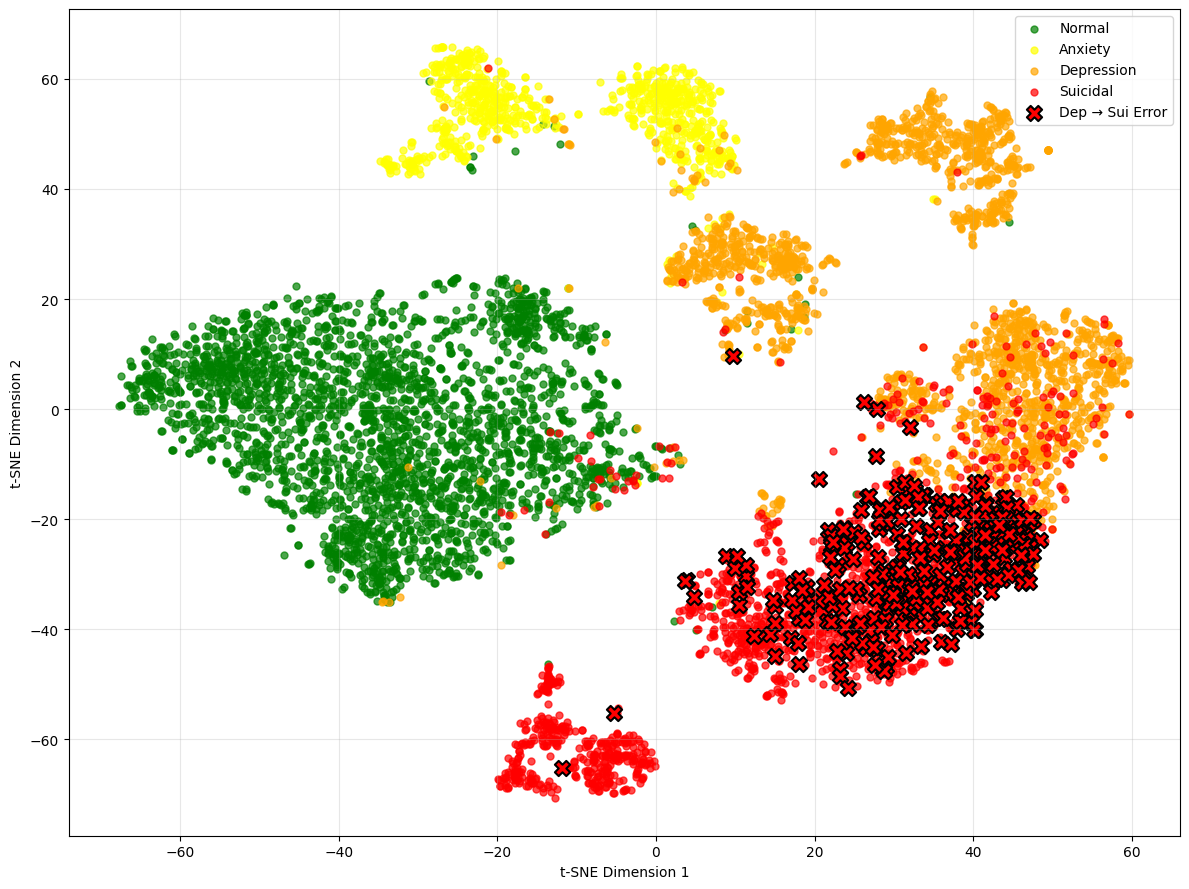


正在计算 UMAP...


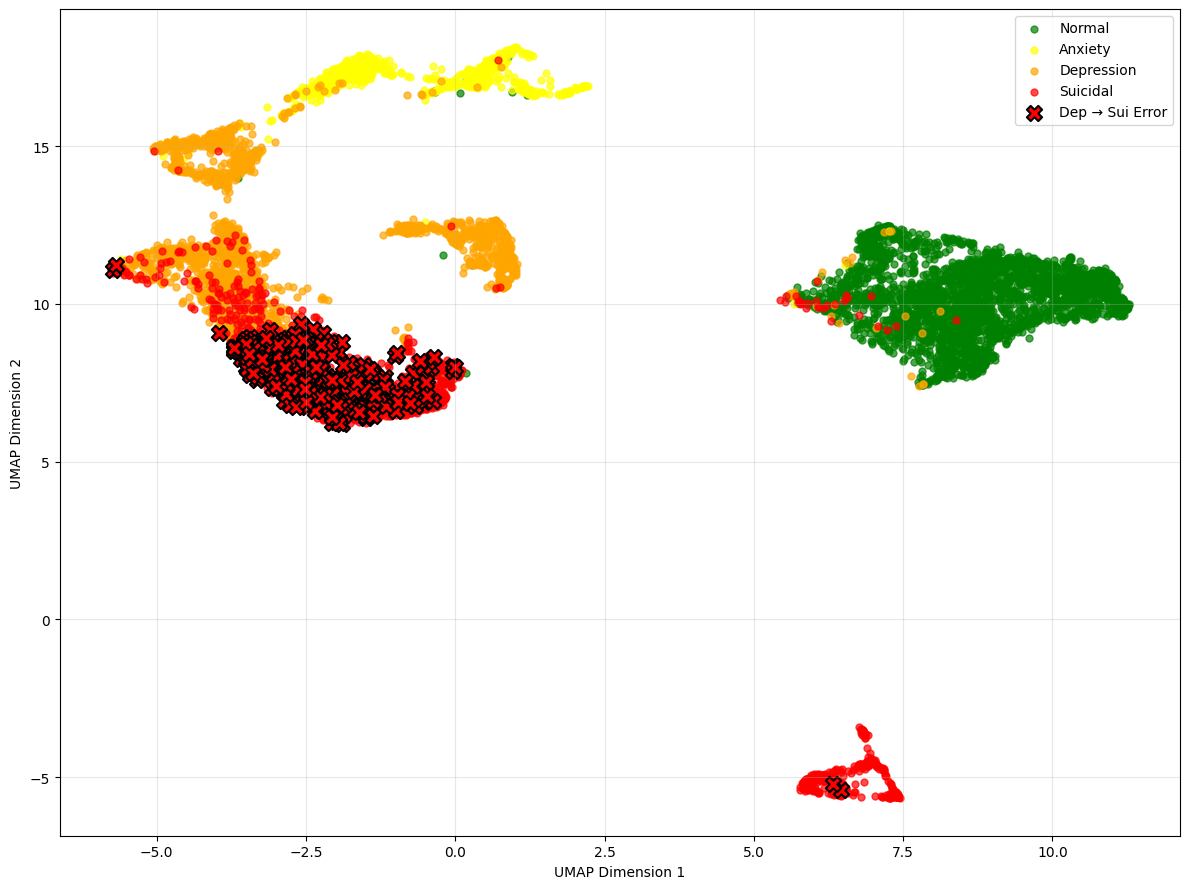


分析完成！
生成文件：
1. tsne_with_errors.png
2. umap_with_errors.png


In [2]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import euclidean_distances
import umap
import matplotlib.pyplot as plt
from tqdm import tqdm
import os
import random
import warnings

warnings.filterwarnings("ignore")

# ====================== 随机种子 & 设备 ======================
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

LOCAL_MODEL_DIR = "./hf_models"
MODEL_PATH = os.path.join(LOCAL_MODEL_DIR, "roberta-base")

CHECKPOINT_PATH = "best_Baseline.pt"   # fine-tune checkpoint

# ====================== 数据加载 ======================
df = pd.read_csv("mental_heath_unbanlanced.csv")
df = df.dropna(subset=["text", "status"])
df["text"] = df["text"].astype(str)

label_encoder = LabelEncoder()
df["label_encoded"] = label_encoder.fit_transform(df["status"])

train_texts, temp_texts, train_labels, temp_labels = train_test_split(
    df["text"].tolist(), df["label_encoded"].tolist(),
    test_size=0.3, random_state=42, stratify=df["label_encoded"]
)

val_texts, test_texts, val_labels, test_labels = train_test_split(
    temp_texts, temp_labels, test_size=0.5, random_state=42, stratify=temp_labels
)

# ====================== Dataset ======================
class TextDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=96):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            truncation=True,
            padding="max_length",
            max_length=self.max_length,
            return_tensors="pt"
        )
        return {
            "input_ids": encoding["input_ids"].squeeze(),
            "attention_mask": encoding["attention_mask"].squeeze(),
            "labels": torch.tensor(self.labels[idx], dtype=torch.long),
            "text": self.texts[idx]
        }

# ====================== 加载 fine-tuned 模型并提取 embedding ======================
print("正在加载 fine-tuned checkpoint 并提取 [CLS] embedding...")

class ClassifierModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(MODEL_PATH, local_files_only=True)
        hidden = self.encoder.config.hidden_size
        self.classifier = nn.Linear(hidden, 4)

    def forward(self, input_ids, attention_mask):
        outputs = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        cls = outputs.last_hidden_state[:, 0, :]
        logits = self.classifier(cls)
        return logits, cls  # 返回 logits 和 cls embedding

tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH, local_files_only=True)
model = ClassifierModel().to(DEVICE)
model.load_state_dict(torch.load(CHECKPOINT_PATH, map_location=DEVICE))
model.eval()

test_dataset = TextDataset(test_texts, test_labels, tokenizer)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

all_embeddings = []
all_true_labels = []
all_texts = []
pred_labels = []

with torch.no_grad():
    for batch in tqdm(test_loader, desc="Extracting embeddings & Predicting"):
        input_ids = batch["input_ids"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)
        
        logits, cls = model(input_ids=input_ids, attention_mask=attention_mask)
        cls = cls.cpu().numpy()
        
        preds = torch.argmax(logits, dim=1).cpu().numpy()
        
        all_embeddings.append(cls)
        all_true_labels.extend(batch["labels"].numpy())
        all_texts.extend(batch["text"])
        pred_labels.extend(preds)

embeddings = np.vstack(all_embeddings)
true_labels = np.array(all_true_labels)
pred_labels = np.array(pred_labels)

print(f"提取完成：{embeddings.shape[0]} 个样本，维度 {embeddings.shape[1]}")

# ====================== 定量指标 ======================
print("\n=== 定量 Embedding 分析 (Fine-tuned) ===")

unique_labels = np.unique(true_labels)
class_names = label_encoder.classes_
centroids = []
intra_vars = []

for i, lbl in enumerate(unique_labels):
    mask = true_labels == lbl
    class_emb = embeddings[mask]
    centroid = np.mean(class_emb, axis=0)
    centroids.append(centroid)
    
    variance = np.mean(np.linalg.norm(class_emb - centroid, axis=1))
    intra_vars.append(variance)
    print(f"Class {class_names[lbl]:<12} variance: {variance:.4f}")

centroids = np.vstack(centroids)
dist_matrix = euclidean_distances(centroids)

print("\nCentroid Distance Matrix:")
for i, name1 in enumerate(class_names):
    for j, name2 in enumerate(class_names):
        if i < j:
            print(f"{name1} ↔ {name2}: {dist_matrix[i,j]:.4f}")

dep_idx = list(class_names).index("Depression")
sui_idx = list(class_names).index("Suicidal")
dep_sui_dist = dist_matrix[dep_idx, sui_idx]
sep_index = dep_sui_dist / (intra_vars[dep_idx] + intra_vars[sui_idx])

print(f"\nDepression ↔ Suicidal centroid distance: {dep_sui_dist:.4f}")
print(f"Dep-Sui separation index: {sep_index:.4f} (值越小，重叠越严重)")

# ====================== t-SNE 可视化 ======================
print("\n正在计算 t-SNE...")
tsne = TSNE(n_components=2, perplexity=30, max_iter=1000, random_state=42, init='pca')
tsne_emb = tsne.fit_transform(embeddings)

plt.figure(figsize=(12, 9))

colors = ['green', 'yellow', 'orange', 'red']  
severity_order = [2, 0, 1, 3]  # Normal(2), Anxiety(0), Depression(1), Suicidal(3)

for idx, orig_lbl in enumerate(severity_order):
    name = class_names[orig_lbl]
    mask = true_labels == orig_lbl
    plt.scatter(tsne_emb[mask, 0], tsne_emb[mask, 1], 
                c=colors[idx], label=name, alpha=0.7, s=25)

# 高亮 Dep → Sui 错误
dep_to_sui_mask = (true_labels == 1) & (pred_labels == 3)
plt.scatter(tsne_emb[dep_to_sui_mask, 0], tsne_emb[dep_to_sui_mask, 1],
            c='red', edgecolors='black', s=120, marker='X', linewidth=1.5, 
            label='Dep → Sui Error')

plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('tsne_with_errors.png', dpi=300, bbox_inches='tight')
plt.show()
#plt.close()

# ====================== UMAP 可视化 ======================
print("\n正在计算 UMAP...")
reducer = umap.UMAP(n_components=2, random_state=42)
umap_emb = reducer.fit_transform(embeddings)

plt.figure(figsize=(12, 9))
for idx, orig_lbl in enumerate(severity_order):
    name = class_names[orig_lbl]
    mask = true_labels == orig_lbl
    plt.scatter(umap_emb[mask, 0], umap_emb[mask, 1], 
                c=colors[idx], label=name, alpha=0.7, s=25)

plt.scatter(umap_emb[dep_to_sui_mask, 0], umap_emb[dep_to_sui_mask, 1],
            c='red', edgecolors='black', s=120, marker='X', linewidth=1.5, 
            label='Dep → Sui Error')

plt.xlabel('UMAP Dimension 1')
plt.ylabel('UMAP Dimension 2')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('umap_with_errors.png', dpi=300, bbox_inches='tight')
plt.show()
#plt.close()

print("\n分析完成！")
print("生成文件：")
print("1. tsne_with_errors.png")
print("2. umap_with_errors.png")